# Python machine learning
<hr>

````{admonition} Goals and prerequisites
:class: tip
**Goals**: 

- Learn and use some common marchine learning methods for data analysis.

**Prerequisites**: 
- Can install and import a Python library.
- Familiar with common data types in Python.
- Can use Pandas and Numpy to process data. 
- Can draw a picture in Python*.
- Can define a Python function*.

**Python libraries used in this chapter**: 
- Matplotlib
- Numpy
- Pandas
- Scikit-learn
- Statsmodels
- Seaborn*
````

In this chapter, we explain how to perform some machine leanrning methods using Python. Rather than delving into the theoretical and computational details of those methods, we aim to provide intuitive, visual explanations that are easy to understand.

One key machine leanring library in Python is `scikit-learn`, which focuses on some classical machine lenarning methods such as linear regression, supoport vector machine, random forest, clustring, and so on. 

Install it using `pip install`:

```bash
pip install scikit-learn
```

When we use this library in Python, its name is `sklearn`.

Another widely used marchine learning library is `PyTorch`, which is deep learning framework and build some deep learning networks like RNN, CNN, Transformer, and so on.

## Linear regression
<hr>

linear regression is a model that estimates the relationship between a scalar `response` (dependent variable) and one or more `explanatory variables` (regressor or independent variable). 

Linear regression is widely used in biological and social sciences to describe possible relationships between variables. It ranks as **one of the most important tools** used in these disciplines.

For example, for a seaborn dataset "car_crashes", which contains data on car crashes in different U.S. states.

In [1]:
import seaborn as sns

crashes = sns.load_dataset('car_crashes')
crashes.head()  

,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses,abbrev
0,18.8,7.332,5.640,18.048,15.040,784.55,145.08,AL
1,18.1,7.421,4.525,16.290,17.014,1053.48,133.93,AK
2,18.6,6.510,5.208,15.624,17.856,899.47,110.35,AZ
3,22.4,4.032,5.824,21.056,21.280,827.34,142.39,AR
4,12.0,4.200,3.360,10.920,10.680,878.41,165.63,CA


Descriptions for each column are below:

| Variable Name       | Description                                                                  |
| ------------------- | ---------------------------------------------------------------------------- |
| `total`             | Total number of car crash deaths per 10,000 people in each state             |
| `speeding`          | Proportion of deaths due to speeding (as a fraction of `total`)              |
| `alcohol`           | Proportion of deaths involving alcohol (as a fraction of `total`)            |
| `not_distracted`    | Proportion of deaths not caused by distraction                           |
| `no_previous`       | Proportion of drivers involved in fatal crashes with no prior violations |                   
| `ins_premium`       | Average insurance paid per driver  |
| `ins_losses`        | Average insurance losses per driver for the insurance company                           |
| `abbrev`            | Two-letter abbreviation of the US state                                      |


A scatter plot for the speeding and total number of crashes is given below.

<Axes: xlabel='speeding', ylabel='total'>

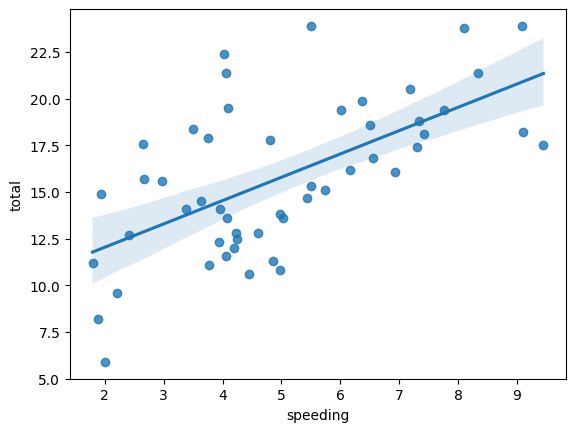

In [2]:
sns.regplot(data=crashes, x="speeding", y="total")

 We may assume there is a linear relationship between the amount of total crashes and the speeding, i.e., 

```{math}
:label: eq-single-variable
\text{total}=\beta_0+\beta_1\text{ speeding}
```

Geometrically, linear regression involves finding **the best-fitting line through a set of points**, represented by a linear equation as shown above, where $\beta_0$ is called the `intercept`.

The most common way to comute the linear regreesion model is by the ordinary least square method, for which we can use the function `OLS()` from the library `Statsmodels`. 

Using the `statsmodels` library to perform regression typically involves the following steps:

* Construct the regression model using the function `OLS()` and `fit()`.
* Output the regression results using the `summary()` function.
* Obtain predicted values using the `predict()` function. This step can be omitted if not for prediction.


In the following code, we build a linear model for the equation {eq}`eq-single-variable` using `statsmodels.formula.api`.

In [3]:
import statsmodels.formula.api as sm

# the linear model is definded by strings the in the formula
model = sm.ols(formula="total ~ speeding", data=crashes).fit()

# model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  total   R-squared:                       0.374
Model:                            OLS   Adj. R-squared:                  0.361
Method:                 Least Squares   F-statistic:                     29.27
Date:                Wed, 06 May 2026   Prob (F-statistic):           1.87e-06
Time:                        19:45:50   Log-Likelihood:                -132.15
No. Observations:                  51   AIC:                             268.3
Df Residuals:                      49   BIC:                             272.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      9.5459      1.243      7.680      0.0

There are a lot of information in the output table, but we usually concern several key informations:

- Values of coefficicent $\beta_0, \beta_1, \dots$
  - They are given in the column "coef". From them, we can get the fitted model. For this example, it is:
    
    $$
    \text{total}=9.5459 +1.2493 \text{ total}\_\text{speed}
    $$
    
- p-values of the independent variables.
  - The p-values are given in the column "P>|t|". If the p-value of an independe variable is less than 0.05, it means there is **linear relationship** between the independent variable and the dependent variable at 95% confidence level. For this example, the p-values for 'speeding' are 0.000. meaning it has strong influence on the car crash deaths.
- $R^2$
  - It is given by the value on the right of "R-squred: " at the top right of the table. It measures the proportion of variability in the dependent variable explained by the model, with a range between 0 and 1. **The closer it is to 1, the better the model fit** (in reasonable business models, $R^2$ should usually be higher than 0.2). For this example, it is 0.374.

- Prob (F-statistic)

  - It is the p-value for the entire model, indicating whether all the independent variables together significantly affect the dependent variable. If Prob (F-statistic) < 0.05, this indicates that the model is statistically significant, meaning at least one of your independent variables has a reliable relationship with the dependent variable; otherwise, it means all the independent variabls do not have much influence on the dependent variable.

In regression analysis, there is no universal threshold for what constitutes a "good" R² value, as it heavily depends on the **field of study and research context**. However, here are some general guidelines:
  - R² > 0.7: Often considered **strong** in social sciences or fields with high noise.  
  - R² = 0.3–0.7: **Moderate** explanatory power (common in economics, biology, etc.).  
  - R² < 0.3: **Weak** fit, but may still be meaningful in noisy domains (e.g., psychology, climate studies).  
  - R² ≈ 0: Model explains almost none of the variability.  

The general syntax for the function `ols()` is given below.

<table>
    <tr style="border-top:solid; border-bottom:solid">
        <th colspan=2 style="text-align:center">statsmodels.formula.api.ols(formula, data)</th>
    </tr>
    <tr>
        <td style="text-align:left">formula</td>
        <td style="text-align:left">Usually a string, the formula specifying the model.</td>
    </tr>
    <tr style="text-align:left; border-bottom:solid" >
        <td style="text-align:left">data</td>
        <td style="text-align:left">Usually a DataFrame or dict, the data for the model</td>
    </tr>
</table>
<br />

The general syntax for the formula is below:

> y ~ x1 + x2 + x1:x2 + C(x3)

- `y` is the dependent (response) variable

- `x1`, `x2`, `x3` are independent (regressor) variables
- `C(x3)` means x3 is catorgorical variable
- `~` separates the dependent variable from the predictors

- `+` adds independent variables

- `-1` removes the intercept (by default it’s included)

- `x1:x2` adds an **interaction term** only, which equals x1*x2

- `x1*x2` adds both main terms and the interaction, which equals x1 + x2 + x1*x2

For example, we can apply a linear regression between the amount of total crashes, the speeding and the alcohol:

$$
\text{total}=\beta_0+\beta_1\text{ speeding}+\beta_2\text{ alcohol}
$$

In [4]:
import statsmodels.formula.api as smf
import seaborn as sns

crashes = sns.load_dataset('car_crashes')

# the linear model is definded by strings the in the formula
model = smf.ols(formula="total ~ speeding + alcohol", data=crashes).fit()

# model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  total   R-squared:                       0.730
Model:                            OLS   Adj. R-squared:                  0.719
Method:                 Least Squares   F-statistic:                     64.87
Date:                Wed, 06 May 2026   Prob (F-statistic):           2.27e-14
Time:                        19:45:50   Log-Likelihood:                -110.71
No. Observations:                  51   AIC:                             227.4
Df Residuals:                      48   BIC:                             233.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.6807      0.957      5.934      0.0

In the regression results, the p-value for 'alcohol' is below 0.001, indicating a statistically significant association with the number of accidents. In contrast, the p-value for 'speeding' is 0.470, which exceeds the conventional 0.05 significance level. This suggests that, after controlling for 'alcohol' consumption, 'speeding' does not have a statistically significant independent effect in this specification of the model. This may be due to the presence of an interaction effect between speeding and alcohol.

### *With interaction terms

Normally in regression, we assume that variables affect the outcome **independently**. But sometimes, the combined effect of two variables is more (or less) than just adding their individual effects — that's where `interaction terms` come in.

For example, if we consider the interaction of speeding and alcohol (drivers with alcohol tend to driving with highe speed):

$$
\text{total}=\beta_0+\beta_1\text{ speeding}+\beta_2\text{ alcohol}+\beta_3\text{ alcohol*speeding}
$$

To mitigate potential collinearity arising from interaction terms, continuous variables were mean-centered prior to analysis. This procedure not only stabilizes the model but also facilitates the interpretation of main effects by representing them at the predictors' average levels.

```{note}
**Collinearity** (or multicollinearity) occurs when two or more predictor variables in a regression model are highly correlated with each other. In other words, one variable can be linearly predicted from the others with a substantial degree of accuracy. 
```

In [5]:
import statsmodels.formula.api as smf
import seaborn as sns

crashes = sns.load_dataset('car_crashes')

# center the continuous variables
crashes['speeding_c'] = crashes['speeding'] - crashes['speeding'].mean()
crashes['alcohol_c'] = crashes['alcohol'] - crashes['alcohol'].mean()

# the linear model is definded by strings the in the formula
# the below code equals: model = smf.ols(formula="total ~ alcohol_c*speeding_c", data=crashes).fit()
model = smf.ols(formula="total ~ speeding_c + alcohol_c + alcohol_c:speeding_c", data=crashes).fit()

# model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  total   R-squared:                       0.790
Model:                            OLS   Adj. R-squared:                  0.777
Method:                 Least Squares   F-statistic:                     58.91
Date:                Wed, 06 May 2026   Prob (F-statistic):           5.91e-16
Time:                        19:45:50   Log-Likelihood:                -104.31
No. Observations:                  51   AIC:                             216.6
Df Residuals:                      47   BIC:                             224.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               16.4228 

The interaction term is statistically significant ($p = 0.001$), indicating a robust joint effect on total car crashes. The negative coefficient (-0.2761) suggests a negative moderatio): specifically, the positive association between 'alcohol' and crash frequency diminishes as 'speeding' levels increase.

### *With catogorical variabls

For the catogorical variable, we use the dataset "tips" as an example to fit the following equation:

In [6]:
import statsmodels.formula.api as smf
import seaborn as sns

tips = sns.load_dataset('tips')
tips.tail(10)

,total_bill,tip,sex,smoker,day,time,size
234,15.53,3.00,Male,Yes,Sat,Dinner,2
235,10.07,1.25,Male,No,Sat,Dinner,2
236,12.60,1.00,Male,Yes,Sat,Dinner,2
237,32.83,1.17,Male,Yes,Sat,Dinner,2
238,35.83,4.67,Female,No,Sat,Dinner,3
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2
243,18.78,3.00,Female,No,Thur,Dinner,2


To examine whether the day of the week significantly affects the tips, we specify the following linear regression formula in Statsmodel:

> tip ~ C(day)

- The catogrical variable is  put in the parenthesis of `C( )` in Statsmodel's formula.

To perform the regression with catogorical variables, Statsmodels follows these steps:

- Identification of Categories: It identifies all unique levels within the variable (e.g., Fri, Sat, Sun, Thur).
- Establishing a Reference Group: It automatically picks one category as the baseline (usually the one that comes first alphabetically). In this example, Thursday was chosen as the reference. If want to specify the reference category, use `Treatment(reference=...)` incide `C( )`.
- Creating $n-1$ Binary Columns: For a variable with $n$ categories, it creates $n-1$ new columns. For each observation:
    - If the day is "Sun", the T.Sun column gets a 1, and all other day columns get a 0.
    - If the day is the reference group ("Thur"), all created columns get a 0.

Therefore, the actural linear regression model mathematically is :

$$
\text{tip}=\beta_0+\beta_1\text{Friday}+\beta_2\text{Tuesday}+\beta_3\text{Sunday}
$$

- The Intercept ($\beta_0$): represents the mean of the Reference Group (Thursday).
- The Coefficients ($\beta_1, \beta_2, \beta_3$): represent the difference between that specific day and the reference group.

In [7]:
import statsmodels.formula.api as smf
import seaborn as sns

tips = sns.load_dataset('tips')

# the linear model is definded by strings the in the formula
model = smf.ols(formula="tip ~ C(day)", data=tips).fit()

# model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    tip   R-squared:                       0.020
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     1.672
Date:                Wed, 06 May 2026   Prob (F-statistic):              0.174
Time:                        19:45:50   Log-Likelihood:                -422.43
No. Observations:                 244   AIC:                             852.9
Df Residuals:                     240   BIC:                             866.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         2.7715      0.175     15.837

$R^2$ is only 0.02. This means that 'day of the week' accounts for only 2% of the variance in tip amounts. The vast majority of the variation in tips is determined by other factors, such as total bill.

Based on the results, the model selected Thursday as the reference group (as it is excluded from the coefficient list).

- Intercept (2.7715): Represents the mean tip level for Thursday.
- C(day)[T.Fri] (-0.0367, $p=0.919$): the average tip on Friday is 0.037 less than on Thursday.
    - However, the $p$-value is nearly 1, indicating no significant difference between Friday and Thursday.
- C(day)[T.Sat] (0.2217, $p=0.334$): the average tip on Saturday is 0.22 more than on Thursday.
    - With $p > 0.05$, this difference is likewise not statistically significant.
- C(day)[T.Sun] (0.4837, $p=0.041$): the average tip on Sunday is 0.48 more than on Thursday.
    - Significance: The $p$-value of 0.041 is statistically significant at the 0.05 level. This indicates that within this sample, tips on Sunday are significantly higher than those on Thursday."

Specify 'Friday' as the reference category:

In [8]:
import statsmodels.formula.api as smf
import seaborn as sns

tips = sns.load_dataset('tips')

# the linear model is definded by strings the in the formula
# Specify the reference category using Treatment(reference=...)
model = smf.ols(formula="tip ~ C(day, Treatment(reference='Fri'))", data=tips).fit()

# model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    tip   R-squared:                       0.020
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     1.672
Date:                Wed, 06 May 2026   Prob (F-statistic):              0.174
Time:                        19:45:50   Log-Likelihood:                -422.43
No. Observations:                 244   AIC:                             852.9
Df Residuals:                     240   BIC:                             866.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

Add 'total_bill' to the model:
> tip ~ total_bill + C(day)

In [9]:
import statsmodels.formula.api as smf
import seaborn as sns

tips = sns.load_dataset('tips')

# the linear model is definded by strings the in the formula
model = smf.ols(formula="tip ~ total_bill + C(day)", data=tips).fit()

# model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    tip   R-squared:                       0.459
Model:                            OLS   Adj. R-squared:                  0.450
Method:                 Least Squares   F-statistic:                     50.67
Date:                Wed, 06 May 2026   Prob (F-statistic):           7.52e-31
Time:                        19:45:50   Log-Likelihood:                -350.03
No. Observations:                 244   AIC:                             710.1
Df Residuals:                     239   BIC:                             727.5
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         0.9205      0.186      4.943

After controlling for total_bill, the previously significant effect of Sunday disappeared ($p$ increased from 0.041 to 0.599). This suggests that the higher tips observed on Sundays were driven by higher consumption amounts rather than a day-specific tipping behavior. The total_bill emerged as the primary predictor, with a significant coefficient of 0.1047 ($p < 0.001$), accounting for nearly 46% of the variance in tip amounts

- To explore whether other variables affect tipping behavior, we can use a hierarchical approach, adding factors step-by-step. The optimal model is then identified by comparing the resulting AIC or BIC and Adjusted $R^2$ values.

### *Detailed explanation of the regression results from Statsmodels

To understand the Statsmodels OLS (Ordinary Least Squares) output as show in the several tables above, it is helpful to divide the results into three main sections: **Model Fit Summary**, **Coefficient Estimates**, and **Diagnostic Tests**.

Here is a detailed breakdown of each statistical value:

1. Model Fit Summary: this section tells you how well your independent variables (like total_bill and day) explain the dependent variable (tip).
   - R-squared ($R^2$): The proportion of the variance for the dependent variable that's explained by the independent variables.
   - Adj. R-squared: A modified version of $R^2$ that accounts for the number of predictors. It only increases if the new term improves the model more than would be expected by chance.
   - F-statistic: Tests whether the model with predictors is significantly better than a model with no predictors (the intercept-only model).
   - Prob (F-statistic): The p-value for the overall model. A value < 0.05 indicates the model is statistically significant.
   - Log-Likelihood: A measure of how well the model fits the data. Higher (less negative) is better.
   - AIC / BIC: Information criteria used for model selection. They penalize complexity; lower values indicate a better balance between fit and simplicity.

2. Coefficient Estimates: this section describes the relationship between each specific predictor and the dependent variable.
   - coef (Coefficient): The estimated change in the dependent variable for every 1-unit increase in the independent variable.
   - std err (Standard Error): Measures the accuracy of the coefficient estimate. Smaller values indicate more precise estimates.
   - t (t-statistic): The coefficient divided by its standard error. It measures how many standard deviations the coefficient is away from zero.
   - P > |t| (p-value): Tests the null hypothesis that the coefficient is zero. If < 0.05, the variable is a significant predictor. 
   - [0.025, 0.975]: The 95% Confidence Interval. If this range does not include zero, the variable is generally considered significant.

3. Diagnostic Tests: these values check if your data meets the mathematical assumptions of linear regression.
   - Omnibus / Prob(Omnibus): Tests the skewness and kurtosis of the residuals. We want Prob(Omnibus) to be high (> 0.05) to indicate normally distributed residuals.
       - A very small Prob(Omnibus) value suggests that the model may suffer from omitted variable bias, the presence of outliers, or a non-linear relationship that requires a mathematical transformation of the dependent variable (such as a log transformation). 
   - Skew (Skewness): Measures the asymmetry of the residuals. Zero is perfectly symmetrical. Negative skew: the left tail is longer. Postive skew: the right tail is longer.
   - Kurtosis: Measures the "fatness" of the tails of the residual distribution. A normal distribution has a kurtosis of 3.
   - Durbin-Watson: Tests for autocorrelation in the residuals. Values near 2.0 mean no autocorrelation. Its value for a reasonable model should be between 1 and 3.
   - Jarque-Bera (JB) / Prob(JB): Another test for the normality of residuals. Like Omnibus, we generally want a high p-value here.
   - Cond. No. (Condition Number): Tests for multicollinearity. If this value is very high (> 1000 for business models), the independent variables may be too highly correlated with each other.
    - In business models, when the condition number is greater than 1000, researchers typically calculate the variance inflation factor (VIF) for each explanatory variable to further assess multicollinearity.

```{note}
Linear regression can also be performed using non-formula-based modeling, non-OLS methods or other libraries, which are omitted here due to space limitations.
```

## Standardize Data
<hr>

`Standardization` is a process of transforming the data to make it more suitable for some statistical analysis or machine learning. 

The main reasons include:

- To remove the effect of different units and scales

  * Variables may have different units (e.g., dollars, percentages, counts).
  * Without standardization, variables with larger scales may dominate the model (especially in regression or distance-based models like KNN, SVM).

- To compare variable importance

  * In regression, standardized coefficients allow you to compare which variable has a stronger effect on the outcome. Standarization is usually operational for OLS regression, but suggested for non-OLS regreesino such as Ridge/Lasso/Elastic Net regression.
 
- To improve model performance

  * Many machine learning models (e.g., gradient descent-based, PCA, K-means) work better when input features are on similar scales.

- To meet assumptions of some statistical tests

  * Some models assume variables are normally distributed or centered around 0, especially in multivariate analysis.

There are two common methods for standardizing data: z-score standardization and min-max standardization

### Z-score Standardization (`StandardScaler`)

Transforms data to have mean ($\mu$) = 0 and standard deviation ($\sigma$) = 1.

$$
z = \frac{x - \mu}{\sigma}
$$

In python, it is easy to standardize the data with the method `fit_transform( )` from `sklearn`.

In [10]:
from sklearn.preprocessing import StandardScaler
import seaborn as sns

crashes = sns.load_dataset('car_crashes')
scaler = StandardScaler()
crash_standard = scaler.fit_transform(crashes.iloc[:, 0:-1]) # standard
print(crash_standard[1:10]) # print the first 10 rows

[[ 0.56593556  1.2126951  -0.21131068  0.60853209  0.80725756  0.94325764
  -0.02289992]
 [ 0.68844283  0.75670887  0.18761539  0.45935701  1.03314134  0.0708756
  -0.98177845]
 [ 1.61949811 -0.48361373  0.54740815  1.67605228  1.95169961 -0.33770122
   0.32112519]
 [-0.92865317 -0.39952407 -0.8917629  -0.594276   -0.89196792 -0.04841772
   1.26617765]
 [-0.5366299   0.01692    -0.63009543 -0.63369765 -0.29104195 -0.2914793
   0.22027622]
 [-1.22267063 -0.01511416 -0.5833691  -0.9356316  -1.38129335  1.02964051
   1.32270187]
 [ 0.10040792  0.57951992 -0.01564416  0.1166575   0.54542553  1.42128062
   0.6907692 ]
 [-2.42324191 -1.49769509 -1.92383077 -1.71868879 -2.17430102  2.19175919
   0.06330968]
 [ 0.51693265 -0.62025945  0.17768604  0.64840171  0.7568227   1.54737129
   0.39391538]]


- For the input parmater X in the method `fit_transform(X)`, X is an array-like of shape (n_samples, n_features).

### Min-Max Normalization

This method scales data to the **\[0, 1]** range by default.

$$
x' = \frac{x - \min(x)}{\max(x) - \min(x)}
$$

In [11]:
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns

crashes = sns.load_dataset('car_crashes')
scaler = MinMaxScaler()
crash_standard = scaler.fit_transform(crashes.iloc[:, 0:-1]) # min-max
print(crash_standard[1:10]) # print the first 10 rows

[[0.67777778 0.73504832 0.34718769 0.66344003 0.72262679 0.62393111
  0.45684192]
 [0.70555556 0.61608775 0.42806394 0.63303046 0.77737321 0.39042695
  0.24636258]
 [0.91666667 0.29250457 0.50100651 0.88105566 1.         0.28106617
  0.5323574 ]
 [0.33888889 0.31444241 0.20923623 0.41824574 0.31079324 0.35849657
  0.73980184]
 [0.42777778 0.42308697 0.26228538 0.41020958 0.45643693 0.29343805
  0.51022048]
 [0.27222222 0.41472969 0.27175844 0.34865988 0.19219766 0.64705258
  0.75220923]
 [0.57222222 0.56986158 0.38685613 0.56317063 0.65916775 0.75188004
  0.61349638]
 [0.         0.02794463 0.         0.18903246 0.         0.95810844
  0.47576542]
 [0.66666667 0.25685558 0.42605092 0.67156751 0.71040312 0.78562981
  0.54833527]]


- There is no negative values after standarization for this method.
- Inverse standardization can be through the method `inverse_transform()`. 

In [12]:
scaler.inverse_transform(crash_standard)

array([[  18.8  ,    7.332,    5.64 ,   18.048,   15.04 ,  784.55 ,
         145.08 ],
       [  18.1  ,    7.421,    4.525,   16.29 ,   17.014, 1053.48 ,
         133.93 ],
       [  18.6  ,    6.51 ,    5.208,   15.624,   17.856,  899.47 ,
         110.35 ],
       [  22.4  ,    4.032,    5.824,   21.056,   21.28 ,  827.34 ,
         142.39 ],
       [  12.   ,    4.2  ,    3.36 ,   10.92 ,   10.68 ,  878.41 ,
         165.63 ],
       [  13.6  ,    5.032,    3.808,   10.744,   12.92 ,  835.5  ,
         139.91 ],
       [  10.8  ,    4.968,    3.888,    9.396,    8.856, 1068.73 ,
         167.02 ],
       [  16.2  ,    6.156,    4.86 ,   14.094,   16.038, 1137.87 ,
         151.48 ],
       [   5.9  ,    2.006,    1.593,    5.9  ,    5.9  , 1273.89 ,
         136.05 ],
       [  17.9  ,    3.759,    5.191,   16.468,   16.826, 1160.13 ,
         144.18 ],
       [  15.6  ,    2.964,    3.9  ,   14.82 ,   14.508,  913.15 ,
         142.8  ],
       [  17.5  ,    9.45 ,    7.175,   14.

We can also specify the desired scaling range by using the `feature_range` parameter in `MinMaxScaler()`.

In [13]:
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns

crashes = sns.load_dataset('car_crashes')
scaler = MinMaxScaler(feature_range=(-1, 1))
crash_standard = scaler.fit_transform(crashes.iloc[:, 0:-1]) # min-max
print(crash_standard[1:10]) # print the first 10 rows

[[ 0.35555556  0.47009663 -0.30562463  0.32688005  0.44525358  0.24786221
  -0.08631617]
 [ 0.41111111  0.2321755  -0.14387211  0.26606091  0.55474642 -0.2191461
  -0.50727484]
 [ 0.83333333 -0.41499086  0.00201303  0.76211132  1.         -0.43786767
   0.06471481]
 [-0.32222222 -0.37111517 -0.58152753 -0.16350852 -0.37841352 -0.28300685
   0.47960368]
 [-0.14444444 -0.15382606 -0.47542925 -0.17958084 -0.08712614 -0.4131239
   0.02044095]
 [-0.45555556 -0.17054061 -0.45648313 -0.30268024 -0.61560468  0.29410516
   0.50441846]
 [ 0.14444444  0.13972317 -0.22628774  0.12634126  0.3183355   0.50376008
   0.22699277]
 [-1.         -0.94411073 -1.         -0.62193507 -1.          0.91621687
  -0.04846916]
 [ 0.33333333 -0.48628885 -0.14789816  0.34313502  0.42080624  0.57125963
   0.09667053]]


```{note}
Both the `StandardScaler` and `MinMaxScaler` only accept 2-D data as inputs, i.e., the data shape is (n_samples, n_features).
```

## *Principle component analysis (PCA)
<hr>

Principal component analysis (PCA) is a **dimensionality reduction** to simplify a large data set into a smaller set, while preserving their most important structures. 

It represent a transformation of the original variables into a new set of uncorrelated variables through linear combinations. This transformation is structured such that the leading components account for the **maximal possible information (reflected by the data variance)** in the data, effectively compressing the key information into fewer dimensions.

- For example, there are 4 features in the original data set. We can use PCA to reduce the number of variables to 3 and keep 85% of the original information.

In [14]:
import seaborn as sns

data = sns.load_dataset("iris")
data

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


There are 4 variables in addition to the last categorical variable. We use the class `PCA` from the libraray `sklearn` for reducing to 2 varaibles.

In [15]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
iris_standard = scaler.fit_transform(data.iloc[:, 0:-1])
pca = PCA(n_components=2)  # the number of principal components
pca.fit(iris_standard)  # fit the data by PCA
print(
    f"explained variance of each principal component: {pca.explained_variance_ratio_}"
)  # output the explained variance ratio

principal_components = pca.fit_transform(iris_standard)
print(f"principal components shown the first 10 rows:\n {principal_components[0:10]}")

explained variance of each principal component: [0.72962445 0.22850762]
principal components shown the first 10 rows:
 [[-2.26470281  0.4800266 ]
 [-2.08096115 -0.67413356]
 [-2.36422905 -0.34190802]
 [-2.29938422 -0.59739451]
 [-2.38984217  0.64683538]
 [-2.07563095  1.48917752]
 [-2.44402884  0.0476442 ]
 [-2.23284716  0.22314807]
 [-2.33464048 -1.11532768]
 [-2.18432817 -0.46901356]]


- It is recommended to standarizing the data before applying PCA.
- Specify the number of principal components through the parameter `n_components` in `PCA( )`.
- Fit the data by PCA through the method `fit( )`.
- Usually, the cumulated explained variance ratio of the specified principal components should be greather equal than 85%.
  - In this example, the cumluated explained variance ratiso is 0.729 + 0.228 = 0.954 > 0.85.

- Get the principal components (the values of the reduced variables) by the method `fit_transform( )`.
- The results of PCA may vary each time it is run unless you set the `random_state` parameter in `PCA( )`.

```{note}
PCA is generally used as an intermediate step in data analysis. It is often applied for dimensionality reduction before further tasks such as clustering, classification, or visualization.
```

*The solution to principal component analysis (PCA) is generally obtained via eigenvalue decomposition. Specifically, one computes the eigenvectors corresponding to the largest eigenvalues of the covariance matrix or the correlation matrix of the original data. The eigenvector associated with the largest eigenvalue is the first principal component, the eigenvector associated with the second largest eigenvalue is the second principal component, and the remaining principal components are obtained in descending order accordingly. The proportion of variance explained (also called the contribution rate) of each principal component is defined as the ratio of its corresponding eigenvalue to the sum of all eigenvalues.

## K-means Clustering
<hr>

K-means is a dynamic clustering method. Its basic idea is as follows: first, randomly select K points as the initial centroids, and assign points to K clusters based on the nearest distance principle; then, recalculate the centroids of the K clusters as the new centroids, and reassign points according to the nearest distance principle; this process is repeated until the centroids no longer change.

Now, we use K-means to cluster the iris data.

- Specify the number of clusters through the parameter `n_clusters` in `KMeans( )`.
- Get the clustering result by the method `fit_predict( )`.
- Get the clusgtering centers by the attribute `cluster_centers_`.

```{note}
Both sklearn and seaborn provide datasets for data analysis, but their formats differ. Seaborn datasets are returned as Pandas DataFrames, while scikit-learn datasets are provided as objects with attributes.
```

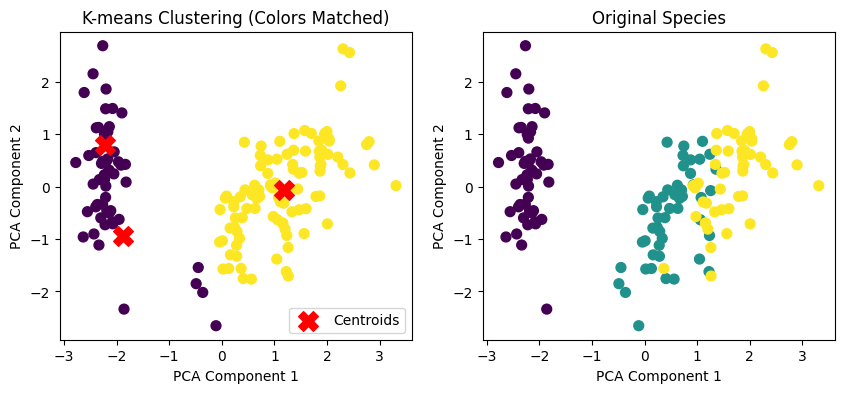

In [16]:
# Import libraries
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import numpy as np
from scipy.stats import mode
from sklearn.preprocessing import StandardScaler

# Load Iris dataset and standardize
iris = datasets.load_iris()
# standardize
scaler = StandardScaler()
X = scaler.fit_transform(iris.data) # visit the data values by visiting the data attribute
y_true = iris.target  # Original species labels

# Apply K-means clustering
kmeans = KMeans(n_clusters=3)
y_pred = kmeans.fit_predict(X)

# * Map K-means labels to match true labels (for consistent colors)
labels_mapped = np.zeros_like(y_pred)
for i in range(3):
    mask = (y_pred == i)
    # mode computation
    # set the predicted label corresponding to the true label
    labels_mapped[mask] = mode(y_true[mask])[0]

# Reduce to 2D for visualization
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)
centers_2d = pca.transform(kmeans.cluster_centers_)

# Plot side by side: K-means vs True labels with consistent colors
fig, axes = plt.subplots(1, 2, figsize=(10,4))

# Left: K-means clusters (mapped)
# 'viridis' is the name of a predefined colormap in Matplotlib.
# It defines a gradient of colors that Matplotlib uses to map numeric values to colors.
# 'viridis' specifically is a smooth gradient from dark purple → blue → green → yellow.
axes[0].scatter(X_2d[:,0], X_2d[:,1], c=labels_mapped, cmap='viridis', s=50)
axes[0].scatter(centers_2d[:,0], centers_2d[:,1], c='red', s=200, marker='X', label='Centroids')
axes[0].set_title("K-means Clustering (Colors Matched)")
axes[0].set_xlabel("PCA Component 1")
axes[0].set_ylabel("PCA Component 2")
axes[0].legend()

# Right: Original species
axes[1].scatter(X_2d[:,0], X_2d[:,1], c=y_true, cmap='viridis', s=50)
axes[1].set_title("Original Species")
axes[1].set_xlabel("PCA Component 1")
axes[1].set_ylabel("PCA Component 2")

plt.show()

## Artificial neural network (ANN)
<hr>

Artificial neural network tries to imiate the function of a human brain.

How a human brain work: the brain continuously sends and receives electrical and chemical signals throughout the body. Some signals make us feel tired, while others allow us to perceive pain. To accomplish this complex communication, the central nervous system depends on billions of neurons (nerve cells).

Below is picture about the stucture of a neuron.

![bnn](biology_neuro.png)

Neurons typically receive signals through their dendrites and transmit them via their axons to the dendrites of other neurons. They are electrically excitable: when the membrane voltage changes sufficiently within a short time, the neuron generates an all-or-none electrochemical pulse known as an action potential. This pulse propagates rapidly throughout the body.

![ann1](artificial_neuro.png)

The neural network approach is inspired by the biological structure of human neurons. Input signals are first combined through weighted sums (weights $w$ and biases $b$) and then passed through an activation function, which determines the amount of information transmitted. The resulting output signals are finally sent to the next neuron.

The computational principle of artificial neural network algorithms is as follows: input information is propagated forward to produce an output, and the error between the actual output and the expected output is calculated. The network parameters (weights $w$ and biases $b$) are then updated through backpropagation. This process is repeated iteratively, gradually reducing the error during propagation, until it falls below a predefined threshold.

The following is an artificial neural network of two hidder layers and there are 3 neurons in the input, output and each hidder layers.

![ann2](ann.png)

General process for using ANN:

- load data;
- split the data into training and testing sets;
- standaridize the data;
- build the network model and train;
- used the trained network to predict for the test set;
- report the accuracy.

We use the artificial neuron network from sklearn to clasify the iris data.

In [17]:
# Import necessary libraries
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split data into training and testing sets
# stratify=y ensures that the training and test sets maintain the same class proportions as the original dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create and train the artificial neural network
# both hidden layers have 10 neurons
mlp = MLPClassifier(hidden_layer_sizes=(10,10), max_iter=1000, random_state=42)
mlp.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred = mlp.predict(X_test_scaled)

# Report accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Test set accuracy: {accuracy:.2%}")

Test set accuracy: 96.67%


There are more complex and powerful ANN structures, such as:

- Recurrent Neural Networks (RNNs): designed for sequential data like time series, text, or speech; process input step by step, keeping memory of previous steps. Variants:

    - LSTM (Long Short-Term Memory)

    - GRU (Gated Recurrent Unit)


- Convolutional Neural Networks (CNNs): designed for image, video, or spatial data; use convolutional layers to automatically extract features. Examples:

    - LeNet, AlexNet, VGG, ResNet



- Transformers: modern state-of-the-art for natural language processing (NLP), sequences, and even images; use self-attention mechanisms to capture long-range dependencies. Examples:

    - BERT, GPT, Vision Transformer


- Generative Adversarial Networks (GANs): consist of two networks (generator and discriminator) competing; used for image generation, style transfer, and games.

- Graph Neural Networks (GNNs): work with graph-structured data, like social networks or molecular structures. Examples:
    - GCN, GraphSAGE

Those complex networks are usually built using frameworks like `PyTorch` or `TensorFlow`.

## *Support vector machine (SVM)
<hr>

Support vector machines are supervised machine learning algorithms that analyze data for classification and regression analysis.

The geometric idea behind SVM is to find a decision boundary (which is a line in two dimensional space) that separates classes with the maximum possible margin. The data points that lie closest to this boundary are called support vectors.

![svm1](svm1.png)

The following codes apply SVM to classify the Iris dataset.

In [18]:
# Import necessary libraries
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Load the Iris dataset
iris = load_iris()
X = iris.data    # Features
y = iris.target  # Labels

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # stratify ensures class balance
)

# Standardize features (important for SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Fit on training data
X_test_scaled = scaler.transform(X_test)        # Apply same transformation to test data

# Create the SVM classifier (RBF kernel)
svm_clf = SVC(kernel='rbf')
svm_clf.fit(X_train_scaled, y_train)  # Train the SVM on scaled training data

# Make predictions on the test set
y_pred = svm_clf.predict(X_test_scaled)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Test set accuracy: {accuracy:.2%}\n")

Test set accuracy: 96.67%



## *Decision tree leanring

Decision tree learning is a supervised learning method used for classification and regression.

## Exercises
<hr>

```{exercise}
:label: regression
Use the library `statsmodels` to do some linear regressions for the 'tips' dataset in the seaborn library.

```

```{exercise}
:label: kmeans
Use the library `scikit-learn` to do some k-means clustering for the 'penguin' dataset in the seaborn library.

```

```{exercise}
:label: prediction
Use the artificial neural network from the library `scikit-learn` to do some predictions for the 'titanic' dataset in the seaborn library.
```

<script src="https://giscus.app/client.js"
        data-repo="RobinChen121/book-python"
        data-repo-id="R_kgDOOt-49A"
        data-category="General"
        data-category-id="DIC_kwDOOt-49M4C2R1O"
        data-mapping="pathname"
        data-strict="0"
        data-reactions-enabled="1"
        data-emit-metadata="0"
        data-input-position="bottom"
        data-theme="light_protanopia"
        data-lang="en"
        crossorigin="anonymous"
        async>
</script>

<!-- Toogle google translation -->
<div id="google_translate_element"></div>
<script type="text/javascript">
      function googleTranslateElementInit() {
        new google.translate.TranslateElement({ pageLanguage: 'en',
                  includedLanguages: 'en,zh-CN,zh-TW,ja,ko,de,ru,fr,es,it,pt,hi,ar,fa',
layout: google.translate.TranslateElement.InlineLayout.SIMPLE }, 'google_translate_element');
      }
</script>
<script type="text/javascript"
      src="https://translate.google.com/translate_a/element.js?cb=googleTranslateElementInit"
></script>
<br>